Epoch 500/5000, Loss: 0.08087
Epoch 1000/5000, Loss: 0.03471
Epoch 1500/5000, Loss: 0.00271
Epoch 2000/5000, Loss: 0.00063
Epoch 2500/5000, Loss: 0.00025
Epoch 3000/5000, Loss: 0.00013
Epoch 3500/5000, Loss: 0.00009
Epoch 4000/5000, Loss: 0.00007
Epoch 4500/5000, Loss: 0.00007
Epoch 5000/5000, Loss: 0.00007


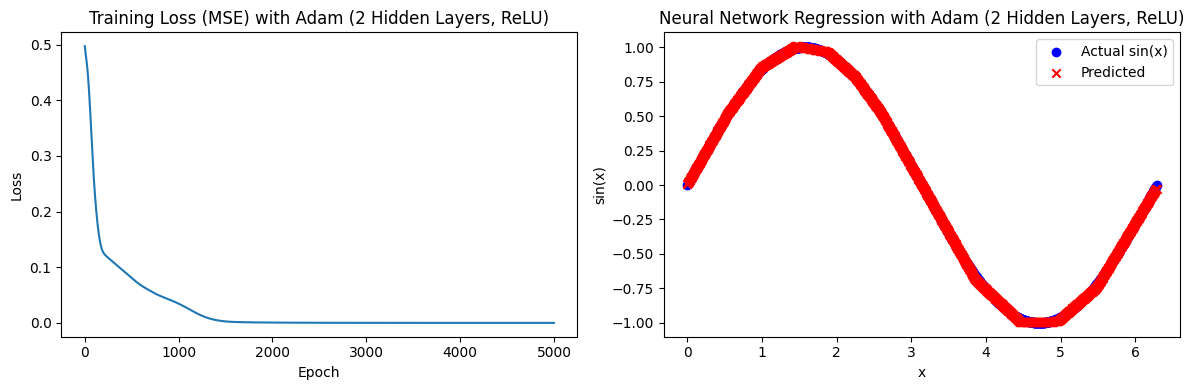

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------
# 1. Generate Dataset: Approximating sin(x)
# -----------------------------------------
np.random.seed(42)
# Create 100 data points between 0 and 2 * pi
x = np.linspace(0, 2 * np.pi, 1000).reshape(-1, 1)
y = np.sin(x)  # True function values

# -----------------------------------------
# 2. Define the Neural Network Architecture
# -----------------------------------------
# Network dimensions: 1 input, hidden neurons in first layer, hidden neurons in second layer, 1 output
input_dim = 1
hidden_dim1 = 20 # First hidden layer size
hidden_dim2 = 10 # Second hidden layer size
output_dim = 1

# Initialize weights and biases (small random values and zeros)
W1 = np.random.randn(input_dim, hidden_dim1) * 0.1
b1 = np.zeros((1, hidden_dim1))
W2 = np.random.randn(hidden_dim1, hidden_dim2) * 0.1 # Weights for second hidden layer
b2 = np.zeros((1, hidden_dim2)) # Biases for second hidden layer
W3 = np.random.randn(hidden_dim2, output_dim) * 0.1 # Weights for output layer
b3 = np.zeros((1, output_dim)) # Biases for output layer

# -----------------------------------------
# 3. Define Activation Functions and Their Derivatives
# -----------------------------------------
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def linear(x):
    # Identity function for regression output
    return x

def linear_derivative(x):
    # Derivative of a linear function is 1
    return 1

# -------------------------------
# 4. Define the Loss Function (MSE)
# -------------------------------
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

# -------------------------------
# 5. Training the Neural Network with Adam Optimizer
# -------------------------------
# Adam optimizer parameters
adam_learning_rate = 0.001 # Base learning rate for Adam
beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8

# Initialize Adam's first and second moment vectors for each parameter
m_W1, v_W1 = np.zeros_like(W1), np.zeros_like(W1)
m_b1, v_b1 = np.zeros_like(b1), np.zeros_like(b1)
m_W2, v_W2 = np.zeros_like(W2), np.zeros_like(W2) # Moments for W2
m_b2, v_b2 = np.zeros_like(b2), np.zeros_like(b2) # Moments for b2
m_W3, v_W3 = np.zeros_like(W3), np.zeros_like(W3) # Moments for W3
m_b3, v_b3 = np.zeros_like(b3), np.zeros_like(b3) # Moments for b3

epochs = 5000       # Number of training epochs
loss_history = []

for epoch in range(1, epochs + 1): # Start epoch from 1 for Adam bias correction
    # ---- Forward Pass ----
    z1 = np.dot(x, W1) + b1        # Linear combination for first hidden layer
    a1 = relu(z1)                 # Activation using relu
    z2 = np.dot(a1, W2) + b2        # Linear combination for second hidden layer
    a2 = relu(z2)                 # Activation using relu for second hidden layer
    z3 = np.dot(a2, W3) + b3        # Linear combination for output layer
    a3 = linear(z3)               # Output (prediction)

    # ---- Compute Loss ----
    loss = mse_loss(y, a3) # Use a3 for loss computation
    loss_history.append(loss)

    # ---- Backward Pass ----
    # Compute gradient of loss with respect to output predictions
    d_loss_a3 = 2 * (a3 - y) / len(x)

    # For the output layer:
    delta3 = d_loss_a3 * linear_derivative(a3)
    dW3 = np.dot(a2.T, delta3)
    db3 = np.sum(delta3, axis=0, keepdims=True)

    # Backpropagate to second hidden layer
    delta2 = np.dot(delta3, W3.T) * relu_derivative(z2)
    dW2 = np.dot(a1.T, delta2)
    db2 = np.sum(delta2, axis=0, keepdims=True)

    # Backpropagate to first hidden layer
    delta1 = np.dot(delta2, W2.T) * relu_derivative(z1)
    dW1 = np.dot(x.T, delta1)
    db1 = np.sum(delta1, axis=0, keepdims=True)

    # ---- Update parameters using Adam ----
    # Update W1
    m_W1 = beta1 * m_W1 + (1 - beta1) * dW1
    v_W1 = beta2 * v_W1 + (1 - beta2) * (dW1 ** 2)
    m_W1_hat = m_W1 / (1 - beta1 ** epoch)
    v_W1_hat = v_W1 / (1 - beta2 ** epoch)
    W1 -= adam_learning_rate * m_W1_hat / (np.sqrt(v_W1_hat) + epsilon)

    # Update b1
    m_b1 = beta1 * m_b1 + (1 - beta1) * db1
    v_b1 = beta2 * v_b1 + (1 - beta2) * (db1 ** 2)
    m_b1_hat = m_b1 / (1 - beta1 ** epoch)
    v_b1_hat = v_b1 / (1 - beta2 ** epoch)
    b1 -= adam_learning_rate * m_b1_hat / (np.sqrt(v_b1_hat) + epsilon)

    # Update W2
    m_W2 = beta1 * m_W2 + (1 - beta1) * dW2
    v_W2 = beta2 * v_W2 + (1 - beta2) * (dW2 ** 2)
    m_W2_hat = m_W2 / (1 - beta1 ** epoch)
    v_W2_hat = v_W2 / (1 - beta2 ** epoch)
    W2 -= adam_learning_rate * m_W2_hat / (np.sqrt(v_W2_hat) + epsilon)

    # Update b2
    m_b2 = beta1 * m_b2 + (1 - beta1) * db2
    v_b2 = beta2 * v_b2 + (1 - beta2) * (db2 ** 2)
    m_b2_hat = m_b2 / (1 - beta1 ** epoch)
    v_b2_hat = v_b2 / (1 - beta2 ** epoch)
    b2 -= adam_learning_rate * m_b2_hat / (np.sqrt(v_b2_hat) + epsilon)

    # Update W3
    m_W3 = beta1 * m_W3 + (1 - beta1) * dW3
    v_W3 = beta2 * v_W3 + (1 - beta2) * (dW3 ** 2)
    m_W3_hat = m_W3 / (1 - beta1 ** epoch)
    v_W3_hat = v_W3 / (1 - beta2 ** epoch)
    W3 -= adam_learning_rate * m_W3_hat / (np.sqrt(v_W3_hat) + epsilon)

    # Update b3
    m_b3 = beta1 * m_b3 + (1 - beta1) * db3
    v_b3 = beta2 * v_b3 + (1 - beta2) * (db3 ** 2)
    m_b3_hat = m_b3 / (1 - beta1 ** epoch)
    v_b3_hat = v_b3 / (1 - beta2 ** epoch)
    b3 -= adam_learning_rate * m_b3_hat / (np.sqrt(v_b3_hat) + epsilon)

    # Optionally print the loss every 500 epochs
    if epoch % 500 == 0:
        print(f"Epoch {epoch}/{epochs}, Loss: {loss:.5f}")

# -------------------------------
# 6. Visualizing Training Loss and Predictions
# -------------------------------
# Plot the loss curve
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title("Training Loss (MSE) with Adam (2 Hidden Layers, ReLU)")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Plot the actual sine function vs. the network's predictions
plt.subplot(1, 2, 2)
plt.scatter(x, y, label="Actual sin(x)", color='blue')
plt.scatter(x, a3, label="Predicted", color='red', marker='x') # Use a3 for predictions
plt.title("Neural Network Regression with Adam (2 Hidden Layers, ReLU)")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------------------------------
# 7. Evaluate and Visualize Predictions on a Wider Range
# -----------------------------------------------------

# Create a new, wider range for evaluation
x_plot = np.linspace(0, 4 * np.pi, 1000).reshape(-1, 1)

# True sine values for the wider range
y_true_plot = np.sin(x_plot)

# Perform forward pass with the trained weights on the new range
z1_plot = np.dot(x_plot, W1) + b1
a1_plot = relu(z1_plot)
z2_plot = np.dot(a1_plot, W2) + b2
a2_plot = relu(z2_plot)
z3_plot = np.dot(a2_plot, W3) + b3
y_pred_plot = linear(z3_plot)

print("Generated predictions for the wider range [0, 4 * pi].")

Generated predictions for the wider range [0, 4 * pi].


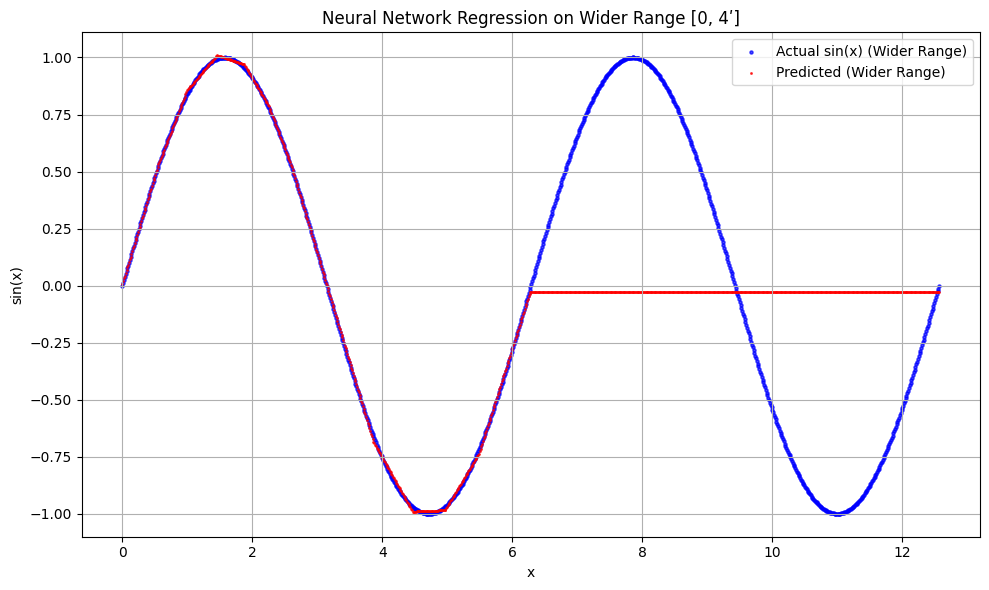

In [ ]:
# Plot the actual sine function vs. the network's predictions for the wider range
plt.figure(figsize=(10, 6))
plt.scatter(x_plot, y_true_plot, label="Actual sin(x) (Wider Range)", color='blue', alpha=0.7, s=5)
plt.scatter(x_plot, y_pred_plot, label="Predicted (Wider Range)", color='red', marker='.', alpha=0.7, s=5)
plt.title("Neural Network Regression on Wider Range [0, 4ʹ]")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 8. Experimenting with Learning Rates

Let's create a function to easily test different learning rates and visualize their impact on the training loss.

In [ ]:
def train_with_learning_rate(learning_rate, epochs, x, y, input_dim, hidden_dim1, hidden_dim2, output_dim):
    # Re-initialize weights and biases for each run
    W1 = np.random.randn(input_dim, hidden_dim1) * 0.1
    b1 = np.zeros((1, hidden_dim1))
    W2 = np.random.randn(hidden_dim1, hidden_dim2) * 0.1
    b2 = np.zeros((1, hidden_dim2))
    W3 = np.random.randn(hidden_dim2, output_dim) * 0.1
    b3 = np.zeros((1, output_dim))

    # Adam optimizer parameters (re-initialize moments)
    beta1 = 0.9
    beta2 = 0.999
    epsilon = 1e-8

    m_W1, v_W1 = np.zeros_like(W1), np.zeros_like(W1)
    m_b1, v_b1 = np.zeros_like(b1), np.zeros_like(b1)
    m_W2, v_W2 = np.zeros_like(W2), np.zeros_like(W2)
    m_b2, v_b2 = np.zeros_like(b2), np.zeros_like(b2)
    m_W3, v_W3 = np.zeros_like(W3), np.zeros_like(W3)
    m_b3, v_b3 = np.zeros_like(b3), np.zeros_like(b3)

    loss_history_lr = []

    for epoch in range(1, epochs + 1):
        # Forward Pass
        z1 = np.dot(x, W1) + b1
        a1 = relu(z1)
        z2 = np.dot(a1, W2) + b2
        a2 = relu(z2)
        z3 = np.dot(a2, W3) + b3
        a3 = linear(z3)

        # Compute Loss
        loss = mse_loss(y, a3)
        loss_history_lr.append(loss)

        # Backward Pass
        d_loss_a3 = 2 * (a3 - y) / len(x)
        delta3 = d_loss_a3 * linear_derivative(a3)
        dW3 = np.dot(a2.T, delta3)
        db3 = np.sum(delta3, axis=0, keepdims=True)

        delta2 = np.dot(delta3, W3.T) * relu_derivative(z2)
        dW2 = np.dot(a1.T, delta2)
        db2 = np.sum(delta2, axis=0, keepdims=True)

        delta1 = np.dot(delta2, W2.T) * relu_derivative(z1)
        dW1 = np.dot(x.T, delta1)
        db1 = np.sum(delta1, axis=0, keepdims=True)

        # Update parameters using Adam
        # Update W1
        m_W1 = beta1 * m_W1 + (1 - beta1) * dW1
        v_W1 = beta2 * v_W1 + (1 - beta2) * (dW1 ** 2)
        m_W1_hat = m_W1 / (1 - beta1 ** epoch)
        v_W1_hat = v_W1 / (1 - beta2 ** epoch)
        W1 -= learning_rate * m_W1_hat / (np.sqrt(v_W1_hat) + epsilon)

        # Update b1
        m_b1 = beta1 * m_b1 + (1 - beta1) * db1
        v_b1 = beta2 * v_b1 + (1 - beta2) * (db1 ** 2)
        m_b1_hat = m_b1 / (1 - beta1 ** epoch)
        v_b1_hat = v_b1 / (1 - beta2 ** epoch)
        b1 -= learning_rate * m_b1_hat / (np.sqrt(v_b1_hat) + epsilon)

        # Update W2
        m_W2 = beta1 * m_W2 + (1 - beta1) * dW2
        v_W2 = beta2 * v_W2 + (1 - beta2) * (dW2 ** 2)
        m_W2_hat = m_W2 / (1 - beta1 ** epoch)
        v_W2_hat = v_W2 / (1 - beta2 ** epoch)
        W2 -= learning_rate * m_W2_hat / (np.sqrt(v_W2_hat) + epsilon)

        # Update b2
        m_b2 = beta1 * m_b2 + (1 - beta1) * db2
        v_b2 = beta2 * v_b2 + (1 - beta2) * (db2 ** 2)
        m_b2_hat = m_b2 / (1 - beta1 ** epoch)
        v_b2_hat = v_b2 / (1 - beta2 ** epoch)
        b2 -= learning_rate * m_b2_hat / (np.sqrt(v_b2_hat) + epsilon)

        # Update W3
        m_W3 = beta1 * m_W3 + (1 - beta1) * dW3
        v_W3 = beta2 * v_W3 + (1 - beta2) * (dW3 ** 2)
        m_W3_hat = m_W3 / (1 - beta1 ** epoch)
        v_W3_hat = v_W3 / (1 - beta2 ** epoch)
        W3 -= learning_rate * m_W3_hat / (np.sqrt(v_W3_hat) + epsilon)

        # Update b3
        m_b3 = beta1 * m_b3 + (1 - beta1) * db3
        v_b3 = beta2 * v_b3 + (1 - beta2) * (db3 ** 2)
        m_b3_hat = m_b3 / (1 - beta1 ** epoch)
        v_b3_hat = v_b3 / (1 - beta2 ** epoch)
        b3 -= learning_rate * m_b3_hat / (np.sqrt(v_b3_hat) + epsilon)

    return loss_history_lr, W1, b1, W2, b2, W3, b3

Training with learning rate: 0.0001
Training with learning rate: 0.001
Training with learning rate: 0.01


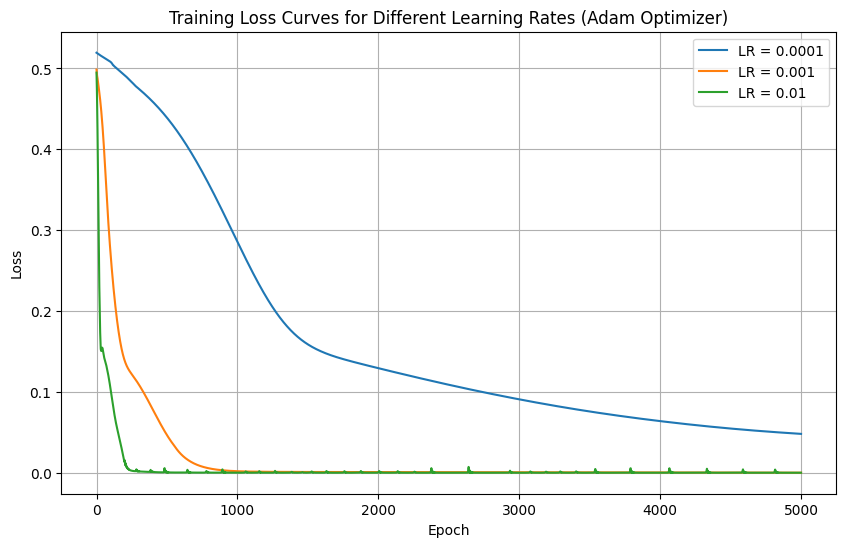

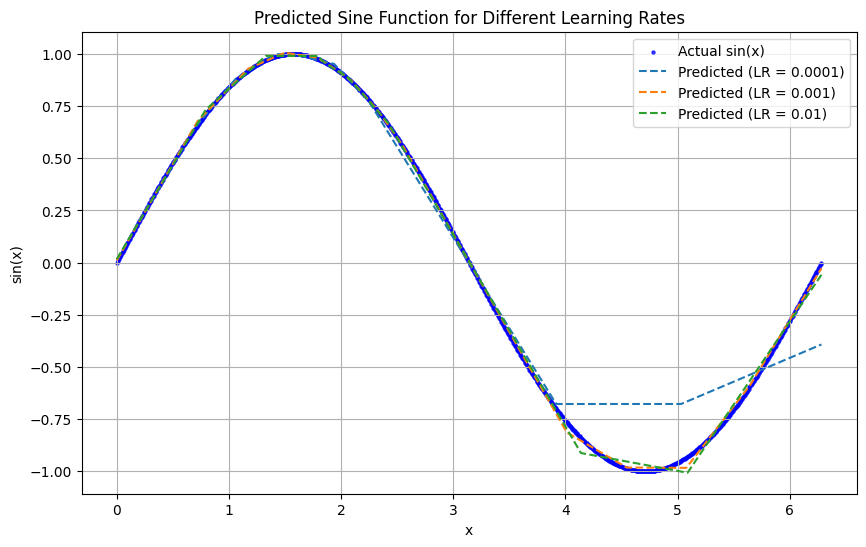

In [ ]:
# Define the learning rates to test
learning_rates_to_test = [0.0001, 0.001, 0.01]
epochs_for_test = 5000 # Increased epochs for longer training

plt.figure(figsize=(10, 6))

for lr in learning_rates_to_test:
    print(f"Training with learning rate: {lr}")
    loss_history_current_lr, W1_final, b1_final, W2_final, b2_final, W3_final, b3_final = train_with_learning_rate(lr, epochs_for_test, x, y, input_dim, hidden_dim1, hidden_dim2, output_dim)
    plt.plot(loss_history_current_lr, label=f'LR = {lr}')

plt.title("Training Loss Curves for Different Learning Rates (Adam Optimizer)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


# Plot the predicted sine function for each learning rate
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label="Actual sin(x)", color='blue', alpha=0.7, s=5)

for lr in learning_rates_to_test:
    # Retrain to get the final weights for this LR (or store them from the previous loop)
    _, W1_final, b1_final, W2_final, b2_final, W3_final, b3_final = train_with_learning_rate(lr, epochs_for_test, x, y, input_dim, hidden_dim1, hidden_dim2, output_dim)

    # Perform forward pass with the trained weights
    z1_pred = np.dot(x, W1_final) + b1_final
    a1_pred = relu(z1_pred)
    z2_pred = np.dot(a1_pred, W2_final) + b2_final
    a2_pred = relu(z2_pred)
    z3_pred = np.dot(a2_pred, W3_final) + b3_final
    y_pred_lr = linear(z3_pred)

    plt.plot(x, y_pred_lr, label=f'Predicted (LR = {lr})', linestyle='--')

plt.title("Predicted Sine Function for Different Learning Rates")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.legend()
plt.grid(True)
plt.show()